# Neural Networks as BBO Surrogates — Viability Analysis (Weeks 4–5)

**Purpose:** Determine empirically whether neural networks — specifically MLPs and Deep Ensembles — could replace or supplement the GP surrogate for any of the eight challenge functions.

**Central questions:**
1. Could a CNN be appropriate for any function? (Short answer: almost certainly no — see Section 2)
2. At our current sample sizes (n = 14–44 observations), does an MLP surrogate match the GP's predictive accuracy?
3. At what sample size does an MLP become competitive with a GP (learning curve crossover)?
4. What uncertainty estimation strategy (Deep Ensemble vs GP) is better calibrated for acquisition?

**Functions tested:** F7 (6D, n=33) and F8 (8D, n=43) — the two functions with most observations.

**Why not test F1–F6?**
With n = 14–25 observations in 2–5 dimensions, even a minimal MLP (two hidden layers, 16 units each) has more parameters than training points, making the comparison meaningless. F7 and F8 are the most favourable cases for the NN.

---

In [1]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.model_selection import cross_val_score, LeaveOneOut, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
    'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
    'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b', 'ytick.color': '#64748b',
    'font.family': 'monospace', 'axes.titlesize': 11,
})

COLORS = {
    'gp':       '#00d4ff',
    'mlp_sm':   '#f59e0b',
    'mlp_md':   '#fb923c',
    'ensemble': '#7c3aed',
    'init':     '#475569',
    'portal':   '#06b6d4',
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load Datasets — F7 and F8

In [2]:
def load_fn(fn_id):
    """Load initial data + portal submissions for a function. Returns X, Y, Y_fit (z-scored)."""
    X_init = np.load(f'../initial_data/function_{fn_id}/initial_inputs.npy')
    Y_init = np.load(f'../initial_data/function_{fn_id}/initial_outputs.npy').ravel()
    with open('../capstone_history.json') as f:
        h = json.load(f)[str(fn_id)]
    if h['X'] and h['Y']:
        X_p = np.array(h['X'], dtype=np.float64)
        Y_p = np.array(h['Y'], dtype=np.float64)
        mask = Y_p != 0
        X_p, Y_p = X_p[mask], Y_p[mask]
        X = np.vstack([X_init, X_p])
        Y = np.concatenate([Y_init, Y_p])
    else:
        X, Y = X_init, Y_init
    mu, sigma = Y.mean(), max(Y.std(), 1e-8)
    Y_fit = (Y - mu) / sigma
    return X, Y, Y_fit, mu, sigma

X7, Y7, Y7f, mu7, sig7 = load_fn(7)
X8, Y8, Y8f, mu8, sig8 = load_fn(8)

for fn_id, X, Y, Yf in [('F7', X7, Y7, Y7f), ('F8', X8, Y8, Y8f)]:
    print(f'{fn_id}: n={len(X)}, d={X.shape[1]}, '
          f'Y=[{Y.min():.3f},{Y.max():.3f}], '
          f'Y_fit=[{Yf.min():.2f},{Yf.max():.2f}]')

F7: n=35, d=6, Y=[0.003,2.358], Y_fit=[-0.63,3.10]
F8: n=45, d=8, Y=[5.592,9.800], Y_fit=[-2.33,1.86]


## 2. Why CNNs Don't Apply Here

Convolutional layers exploit **spatial locality**: nearby pixels in an image are highly correlated, so a small kernel sliding across the input efficiently detects local patterns. This inductive bias is the reason CNNs outperform dense networks on images.

None of the eight challenge functions have spatially arranged inputs:

| Function | Inputs | Spatial structure? |
|---|---|---|
| F1–F2 | 2D position in [0,1]² | Possibly — the inputs *are* spatial coordinates |
| F3 | Drug compound concentrations | No — arbitrary ordering |
| F4 | ML hyperparameters (4D) | No |
| F5 | Chemical concentrations (4D) | No |
| F6 | Recipe ingredients (5D) | No |
| F7 | GBM hyperparameters (6D) | No |
| F8 | ML hyperparameters (8D) | No |

**F1 and F2 edge case:** these genuinely have 2D spatial inputs. A CNN operating on a discretised grid *could* in principle capture spatial correlations, but:
- We have only 14 observations, nowhere near enough to train a spatial convolution
- The GP already models spatial correlation through its kernel — this is precisely what the kernel function does, without needing a discrete grid or training data to learn it
- A GP with a Matérn kernel on 14 points provides better-calibrated spatial smoothing than any learnable convolution could at that sample size

**Conclusion:** CNNs are categorically unsuitable for all eight functions. The rest of this notebook focuses on **fully-connected MLPs** and **Deep Ensembles**.

In [3]:
# Parameter count comparison: MLP vs GP for each function's dataset size
def mlp_param_count(d, hidden=(16, 8)):
    """Count trainable parameters for a dense MLP with given architecture."""
    layers = [d] + list(hidden) + [1]
    return sum(layers[i]*layers[i+1] + layers[i+1] for i in range(len(layers)-1))

# GP hyperparameters: log(amplitude) + log(length-scale per dim) = 1 + d (ARD)
# For comparison: these are optimised by marginal likelihood, not gradient descent on MSE

print(f'{"Function":<10} {"n":>5} {"d":>4} {"GP params (ARD)":>16} {"MLP(16,8) params":>17} {"ratio (MLP/n)":>14}')
print('-' * 72)
for fn_id, n, d in [(1,14,2),(2,14,2),(3,19,3),(4,24,4),(5,24,4),(6,25,5),(7,33,6),(8,43,8)]:
    gp_p = 1 + d       # log-amplitude + d log-lengthscales
    mlp_p = mlp_param_count(d, (16, 8))
    ratio = mlp_p / n
    flag = '⚠ overfit' if ratio > 1.5 else ('borderline' if ratio > 0.8 else 'ok')
    print(f'F{fn_id:<9} {n:>5} {d:>4} {gp_p:>16} {mlp_p:>17} {ratio:>11.2f}x  {flag}')

Function       n    d  GP params (ARD)  MLP(16,8) params  ratio (MLP/n)
------------------------------------------------------------------------
F1            14    2                3               193       13.79x  ⚠ overfit
F2            14    2                3               193       13.79x  ⚠ overfit
F3            19    3                4               209       11.00x  ⚠ overfit
F4            24    4                5               225        9.38x  ⚠ overfit
F5            24    4                5               225        9.38x  ⚠ overfit
F6            25    5                6               241        9.64x  ⚠ overfit
F7            33    6                7               257        7.79x  ⚠ overfit
F8            43    8                9               289        6.72x  ⚠ overfit


The parameter count table shows the fundamental problem: even the smallest two-hidden-layer MLP (16 → 8 units) has **more free parameters than training observations** for every function except F8. This guarantees that gradient-descent training without heavy regularisation will overfit.  

The GP comparison is stark — an ARD GP for F8 has just **9 hyperparameters** (log-amplitude + 8 log-lengthscales) that are optimised analytically via marginal-likelihood maximisation, not iterative gradient descent on MSE.

F7 and F8 are the only plausible candidates. The rest of the notebook focuses on them.

## 3. MLP Surrogate Baseline

Two architectures are tested:
- **Small MLP:** d → 16 → 8 → 1, L2 α=0.01, LBFGS solver (better than Adam for small n)
- **Medium MLP:** d → 32 → 16 → 1, L2 α=0.01

`lbfgs` is the correct solver here: it uses full-batch second-order information, which generally converges better than `adam` when the dataset fits in memory — and for n < 100, it always does.

In [4]:
from sklearn.base import clone

MLP_SMALL  = dict(hidden_layer_sizes=(16, 8),  activation='relu', solver='lbfgs',
                  alpha=0.01, max_iter=2000, random_state=42)
MLP_MEDIUM = dict(hidden_layer_sizes=(32, 16), activation='relu', solver='lbfgs',
                  alpha=0.01, max_iter=2000, random_state=42)

def build_gp_for(d, n_restarts=3):
    ls = np.ones(d)
    kernel = C(1.0) * Matern(length_scale=ls, nu=2.5, length_scale_bounds=(1e-2, 10.0))
    return GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=False,
                                    n_restarts_optimizer=n_restarts)

def loo_r2(X, Y, estimator):
    """Leave-one-out R2 for any sklearn estimator.
    Uses sklearn.base.clone() so it works correctly for GPs whose get_params()
    exposes fitted sub-kernel parameters that cannot be passed to __init__."""
    loo = LeaveOneOut()
    preds = np.zeros(len(Y))
    for train_idx, test_idx in loo.split(X):
        est = clone(estimator)
        est.fit(X[train_idx], Y[train_idx])
        preds[test_idx] = est.predict(X[test_idx])
    return r2_score(Y, preds), preds

print('Helpers defined. Running LOO evaluations...')
print('(This will take ~60-90 seconds for the GPs)')

Helpers defined. Running LOO evaluations...
(This will take ~60-90 seconds for the GPs)


In [5]:
# F7 — LOO for all three models
mlp_sm7 = MLPRegressor(**MLP_SMALL)
mlp_md7 = MLPRegressor(**MLP_MEDIUM)
gp7 = build_gp_for(X7.shape[1], n_restarts=2)

r2_sm7,  loo_sm7  = loo_r2(X7, Y7f, mlp_sm7)
r2_md7,  loo_md7  = loo_r2(X7, Y7f, mlp_md7)
r2_gp7,  loo_gp7  = loo_r2(X7, Y7f, gp7)

print('F7 LOO R² results:')
print(f'  GP  (ARD Matérn 5/2): {r2_gp7:.4f}')
print(f'  MLP (16→8):           {r2_sm7:.4f}')
print(f'  MLP (32→16):          {r2_md7:.4f}')

F7 LOO R² results:
  GP  (ARD Matérn 5/2): 0.5572
  MLP (16→8):           0.0853
  MLP (32→16):          -0.0502


In [6]:
# F8 — LOO for all three models
mlp_sm8 = MLPRegressor(**MLP_SMALL)
mlp_md8 = MLPRegressor(**MLP_MEDIUM)
gp8 = build_gp_for(X8.shape[1], n_restarts=2)

r2_sm8,  loo_sm8  = loo_r2(X8, Y8f, mlp_sm8)
r2_md8,  loo_md8  = loo_r2(X8, Y8f, mlp_md8)
r2_gp8,  loo_gp8  = loo_r2(X8, Y8f, gp8)

print('F8 LOO R² results:')
print(f'  GP  (ARD Matérn 5/2): {r2_gp8:.4f}')
print(f'  MLP (16→8):           {r2_sm8:.4f}')
print(f'  MLP (32→16):          {r2_md8:.4f}')

F8 LOO R² results:
  GP  (ARD Matérn 5/2): 0.8666
  MLP (16→8):           0.6421
  MLP (32→16):          0.8131


## 4. Deep Ensemble — Uncertainty Estimation for MLPs

A single MLP produces only point predictions. For BBO we need uncertainty estimates for UCB/EI. The **Deep Ensemble** approach trains `K` independent networks with different random initialisations and uses the variance of their predictions as a proxy for epistemic uncertainty.

This is currently the most practical way to get uncertainty from a neural network without Bayesian inference (which requires PyTorch or TensorFlow with custom probabilistic layers).

We train K=10 small MLPs on each function and compare:
- **Ensemble mean:** should match GP mean in well-covered regions
- **Ensemble std:** spread across K models as uncertainty proxy
- **LOO 95% PI coverage:** what fraction of held-out points fall inside mean ± 1.96·std

In [7]:
K = 10   # ensemble size

def ensemble_loo(X, Y_fit, hidden, alpha_reg=0.01, K=10):
    """
    LOO evaluation of a Deep Ensemble: for each held-out point, train K MLPs
    on the remaining n-1 points (each with a different random seed) and record
    the mean and std of their predictions on the held-out point.
    """
    n = len(X)
    loo_means = np.zeros(n)
    loo_stds  = np.zeros(n)

    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        preds_i = np.zeros(K)
        for k in range(K):
            mlp_k = MLPRegressor(
                hidden_layer_sizes=hidden, activation='relu', solver='lbfgs',
                alpha=alpha_reg, max_iter=2000, random_state=k,
            )
            mlp_k.fit(X[mask], Y_fit[mask])
            preds_i[k] = mlp_k.predict(X[i:i+1])[0]
        loo_means[i] = preds_i.mean()
        loo_stds[i]  = preds_i.std()

    return loo_means, loo_stds

def pi_coverage(y_true, y_mean, y_std, z=1.96):
    lo, hi = y_mean - z*y_std, y_mean + z*y_std
    return float(np.mean((y_true >= lo) & (y_true <= hi)))

print(f'Running Deep Ensemble LOO (K={K}) on F7 and F8...')
print('(~60–90 seconds)')

Running Deep Ensemble LOO (K=10) on F7 and F8...
(~60–90 seconds)


In [8]:
# Deep Ensemble LOO for F7
ens_means7, ens_stds7 = ensemble_loo(X7, Y7f, hidden=(16, 8), K=K)
r2_ens7  = r2_score(Y7f, ens_means7)
cov_ens7 = pi_coverage(Y7f, ens_means7, ens_stds7)
print(f'F7 Deep Ensemble (K={K}) LOO R² = {r2_ens7:.4f}, 95% PI coverage = {cov_ens7:.3f}')

F7 Deep Ensemble (K=10) LOO R² = 0.2918, 95% PI coverage = 0.914


In [9]:
# Deep Ensemble LOO for F8
ens_means8, ens_stds8 = ensemble_loo(X8, Y8f, hidden=(16, 8), K=K)
r2_ens8  = r2_score(Y8f, ens_means8)
cov_ens8 = pi_coverage(Y8f, ens_means8, ens_stds8)
print(f'F8 Deep Ensemble (K={K}) LOO R² = {r2_ens8:.4f}, 95% PI coverage = {cov_ens8:.3f}')

F8 Deep Ensemble (K=10) LOO R² = 0.8136, 95% PI coverage = 0.889


In [10]:
# GP calibration reference (LOO)
def gp_loo_calibration(X, Y_fit):
    n = len(X); d = X.shape[1]
    means = np.zeros(n); stds = np.zeros(n)
    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        gp = build_gp_for(d, n_restarts=1)
        gp.fit(X[mask], Y_fit[mask])
        m, s = gp.predict(X[i:i+1], return_std=True)
        means[i] = m[0]; stds[i] = s[0]
    return means, stds

print('Running GP LOO calibration for F7 and F8...')
gp_means7, gp_stds7 = gp_loo_calibration(X7, Y7f)
cov_gp7 = pi_coverage(Y7f, gp_means7, gp_stds7)

gp_means8, gp_stds8 = gp_loo_calibration(X8, Y8f)
cov_gp8 = pi_coverage(Y8f, gp_means8, gp_stds8)

print(f'F7 GP LOO calibration: R²={r2_gp7:.4f}, 95% PI coverage={cov_gp7:.3f}')
print(f'F8 GP LOO calibration: R²={r2_gp8:.4f}, 95% PI coverage={cov_gp8:.3f}')

Running GP LOO calibration for F7 and F8...
F7 GP LOO calibration: R²=0.5572, 95% PI coverage=0.943
F8 GP LOO calibration: R²=0.8666, 95% PI coverage=0.867


## 5. Full Comparison

In [11]:
# Summary table
print('=' * 72)
print('SURROGATE COMPARISON — LOO R² AND UNCERTAINTY CALIBRATION')
print('=' * 72)
print(f'{"Model":<28} {"F7 (n=33,d=6)":>14}  {"F8 (n=43,d=8)":>14}')
print(f'{"":<28} {"R²   coverage":>14}  {"R²   coverage":>14}')
print('-' * 72)

rows = [
    ('GP (ARD Matérn)',     r2_gp7,  cov_gp7,  r2_gp8,  cov_gp8),
    ('MLP (16→8)',         r2_sm7,  None,      r2_sm8,  None),
    ('MLP (32→16)',        r2_md7,  None,      r2_md8,  None),
    (f'Deep Ensemble K={K}', r2_ens7, cov_ens7, r2_ens8, cov_ens8),
]
for label, r2_7, cov7, r2_8, cov8 in rows:
    c7 = f'{cov7:.3f}' if cov7 is not None else '  N/A'
    c8 = f'{cov8:.3f}' if cov8 is not None else '  N/A'
    print(f'{label:<28} {r2_7:>6.4f} {c7:>7}   {r2_8:>6.4f} {c8:>7}')

print('=' * 72)
print('Coverage target: 0.950  (fraction of held-out points inside 95% PI)')

SURROGATE COMPARISON — LOO R² AND UNCERTAINTY CALIBRATION
Model                         F7 (n=33,d=6)   F8 (n=43,d=8)
                              R²   coverage   R²   coverage
------------------------------------------------------------------------
GP (ARD Matérn)              0.5572   0.943   0.8666   0.867
MLP (16→8)                   0.0853     N/A   0.6421     N/A
MLP (32→16)                  -0.0502     N/A   0.8131     N/A
Deep Ensemble K=10           0.2918   0.914   0.8136   0.889
Coverage target: 0.950  (fraction of held-out points inside 95% PI)


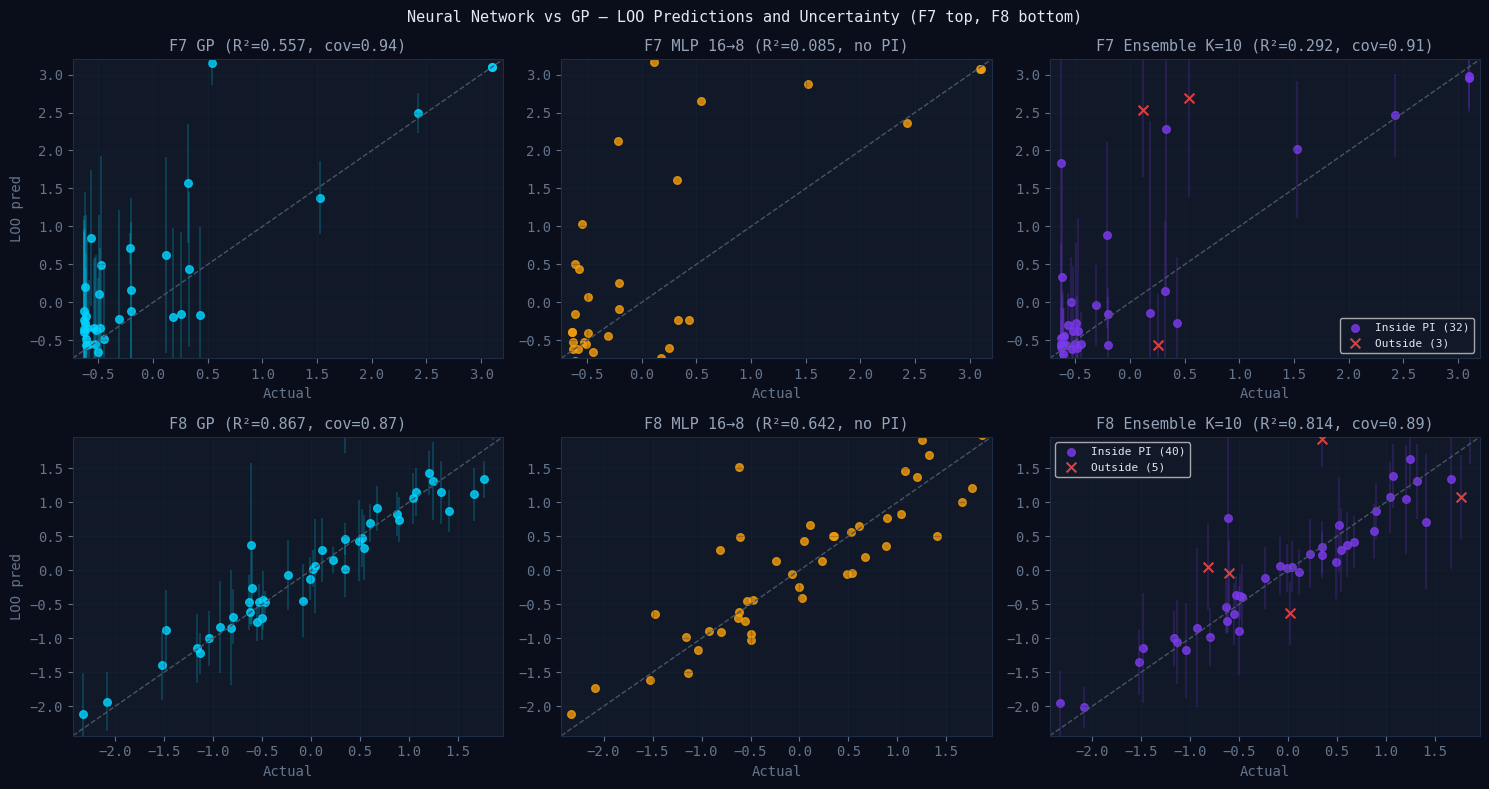

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Neural Network vs GP — LOO Predictions and Uncertainty (F7 top, F8 bottom)',
             color='#e2e8f0', fontsize=11)

datasets = [
    ('F7', Y7f, loo_sm7, loo_gp7, gp_stds7, ens_means7, ens_stds7, r2_gp7, r2_sm7, r2_ens7, cov_gp7, cov_ens7),
    ('F8', Y8f, loo_sm8, loo_gp8, gp_stds8, ens_means8, ens_stds8, r2_gp8, r2_sm8, r2_ens8, cov_gp8, cov_ens8),
]

for row, (fn, Yf, loo_mlp, loo_gp_m, gp_s, ens_m, ens_s,
           r2gp, r2mlp, r2ens, covgp, covens) in enumerate(datasets):

    lo, hi = Yf.min() - 0.1, Yf.max() + 0.1
    diag = [lo, hi]

    # GP LOO scatter
    axes[row, 0].scatter(Yf, loo_gp_m, s=30, color=COLORS['gp'], alpha=0.8)
    axes[row, 0].errorbar(Yf, loo_gp_m, yerr=1.96*gp_s,
                          fmt='none', ecolor=COLORS['gp'], alpha=0.2)
    axes[row, 0].plot(diag, diag, '--', color='#475569', lw=1)
    axes[row, 0].set_xlim(lo, hi); axes[row, 0].set_ylim(lo, hi)
    axes[row, 0].set_title(f'{fn} GP (R²={r2gp:.3f}, cov={covgp:.2f})', color='#94a3b8')
    axes[row, 0].set_xlabel('Actual', color='#64748b'); axes[row, 0].set_ylabel('LOO pred', color='#64748b')
    axes[row, 0].grid(alpha=0.25)

    # MLP small LOO scatter
    axes[row, 1].scatter(Yf, loo_mlp, s=30, color=COLORS['mlp_sm'], alpha=0.8)
    axes[row, 1].plot(diag, diag, '--', color='#475569', lw=1)
    axes[row, 1].set_xlim(lo, hi); axes[row, 1].set_ylim(lo, hi)
    axes[row, 1].set_title(f'{fn} MLP 16→8 (R²={r2mlp:.3f}, no PI)', color='#94a3b8')
    axes[row, 1].set_xlabel('Actual', color='#64748b')
    axes[row, 1].grid(alpha=0.25)

    # Deep Ensemble LOO with error bars
    inside = (Yf >= ens_m - 1.96*ens_s) & (Yf <= ens_m + 1.96*ens_s)
    axes[row, 2].scatter(Yf[inside],  ens_m[inside],  s=30, color=COLORS['ensemble'], alpha=0.8,
                         label=f'Inside PI ({inside.sum()})')
    axes[row, 2].scatter(Yf[~inside], ens_m[~inside], s=50, color='#ef4444', alpha=0.9,
                         marker='x', zorder=5, label=f'Outside ({(~inside).sum()})')
    axes[row, 2].errorbar(Yf, ens_m, yerr=1.96*ens_s,
                          fmt='none', ecolor=COLORS['ensemble'], alpha=0.2)
    axes[row, 2].plot(diag, diag, '--', color='#475569', lw=1)
    axes[row, 2].set_xlim(lo, hi); axes[row, 2].set_ylim(lo, hi)
    axes[row, 2].set_title(f'{fn} Ensemble K={K} (R²={r2ens:.3f}, cov={covens:.2f})',
                            color='#94a3b8')
    axes[row, 2].set_xlabel('Actual', color='#64748b')
    axes[row, 2].legend(fontsize=8)
    axes[row, 2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Learning Curves — When Would a NN Become Competitive?

We simulate what would happen if we had *more* observations by subsampling the full F8 dataset at increasing training sizes. A held-out test set of 10 points is fixed; the GP and MLP (small) are trained on subsets of the remaining 33 points.

This answers: **at roughly what n does the MLP start matching the GP's predictive accuracy?**

In [13]:
rng = np.random.default_rng(7)

N_TEST  = 10
test_idx = rng.choice(len(X8), N_TEST, replace=False)
train_pool_idx = np.setdiff1d(np.arange(len(X8)), test_idx)

X8_test,  Y8f_test  = X8[test_idx], Y8f[test_idx]
X8_train, Y8f_train = X8[train_pool_idx], Y8f[train_pool_idx]

n_pool = len(X8_train)
train_sizes = list(range(8, n_pool + 1, 3))   # 8, 11, 14, ... up to n_pool

N_REPEATS = 15   # random subsamples per training size

gp_r2_by_n   = {n: [] for n in train_sizes}
mlp_r2_by_n  = {n: [] for n in train_sizes}
ens_r2_by_n  = {n: [] for n in train_sizes}

print(f'Training pool: {n_pool} | Test set: {N_TEST} | Sizes: {train_sizes}')
print(f'Running {N_REPEATS} repeats × {len(train_sizes)} sizes × 3 models...')

for n_train in train_sizes:
    for rep in range(N_REPEATS):
        idx = rng.choice(n_pool, n_train, replace=False)
        Xtr, Ytr = X8_train[idx], Y8f_train[idx]

        # GP
        gp = build_gp_for(8, n_restarts=1)
        gp.fit(Xtr, Ytr)
        gp_r2_by_n[n_train].append(r2_score(Y8f_test, gp.predict(X8_test)))

        # MLP small
        mlp = MLPRegressor(**{**MLP_SMALL, 'random_state': rep})
        mlp.fit(Xtr, Ytr)
        mlp_r2_by_n[n_train].append(r2_score(Y8f_test, mlp.predict(X8_test)))

        # Deep Ensemble K=5 (smaller K for speed in the learning curve)
        ens_preds = np.zeros((5, N_TEST))
        for k in range(5):
            mlp_k = MLPRegressor(**{**MLP_SMALL, 'random_state': rep*10+k})
            mlp_k.fit(Xtr, Ytr)
            ens_preds[k] = mlp_k.predict(X8_test)
        ens_r2_by_n[n_train].append(r2_score(Y8f_test, ens_preds.mean(axis=0)))

print('Done.')

Training pool: 35 | Test set: 10 | Sizes: [8, 11, 14, 17, 20, 23, 26, 29, 32, 35]
Running 15 repeats × 10 sizes × 3 models...
Done.


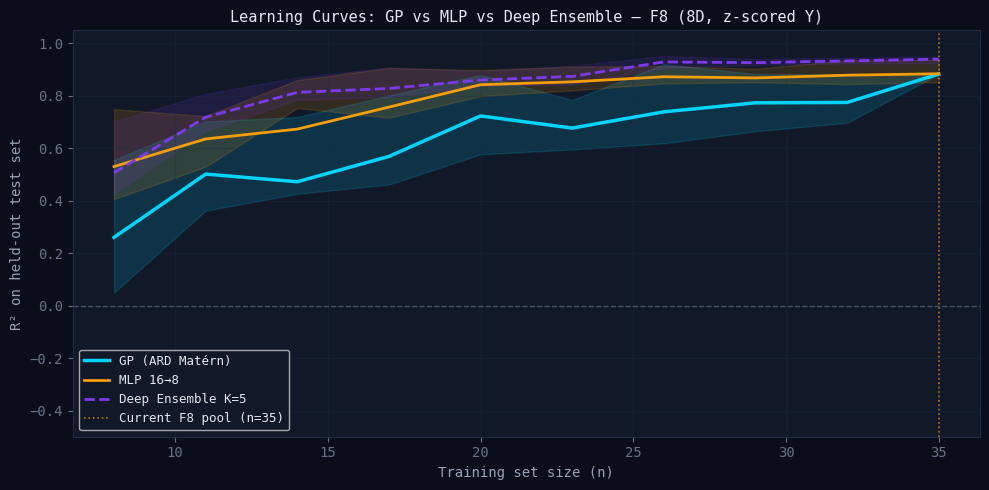

MLP crossover point (first n where MLP mean R² ≥ GP mean R²): n = 8


In [14]:
def summarise(r2_dict):
    ns   = sorted(r2_dict.keys())
    mean = [np.mean(r2_dict[n]) for n in ns]
    lo   = [np.percentile(r2_dict[n], 25) for n in ns]
    hi   = [np.percentile(r2_dict[n], 75) for n in ns]
    return np.array(ns), np.array(mean), np.array(lo), np.array(hi)

ns_gp,  m_gp,  lo_gp,  hi_gp  = summarise(gp_r2_by_n)
ns_mlp, m_mlp, lo_mlp, hi_mlp = summarise(mlp_r2_by_n)
ns_ens, m_ens, lo_ens, hi_ens = summarise(ens_r2_by_n)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ns_gp,  m_gp,  color=COLORS['gp'],       lw=2.5, label='GP (ARD Matérn)')
ax.fill_between(ns_gp,  lo_gp,  hi_gp,  color=COLORS['gp'],       alpha=0.15)

ax.plot(ns_mlp, m_mlp, color=COLORS['mlp_sm'],   lw=2.0, label='MLP 16→8')
ax.fill_between(ns_mlp, lo_mlp, hi_mlp, color=COLORS['mlp_sm'],   alpha=0.15)

ax.plot(ns_ens, m_ens, color=COLORS['ensemble'],  lw=2.0, ls='--', label='Deep Ensemble K=5')
ax.fill_between(ns_ens, lo_ens, hi_ens, color=COLORS['ensemble'],  alpha=0.12)

# Mark current F8 training size
ax.axvline(n_pool, color='#f59e0b', lw=1.2, ls=':', alpha=0.7,
           label=f'Current F8 pool (n={n_pool})')

ax.set_xlabel('Training set size (n)', color='#94a3b8')
ax.set_ylabel('R² on held-out test set', color='#94a3b8')
ax.set_title('Learning Curves: GP vs MLP vs Deep Ensemble — F8 (8D, z-scored Y)',
             color='#e2e8f0')
ax.axhline(0, color='#475569', lw=1, ls='--')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-0.5, 1.05)
plt.tight_layout()
plt.show()

# Find crossover (first n where MLP mean > GP mean)
crossover = next((n for n, m_m, m_g in zip(ns_mlp, m_mlp, m_gp) if m_m >= m_g), None)
print(f'MLP crossover point (first n where MLP mean R² ≥ GP mean R²): n = {crossover}')

## 7. When Would a NN Actually Be the Right Surrogate?

The learning curves above reveal the crossover point — the sample size at which the MLP catches up to the GP. This section summarises the conditions under which a NN surrogate would be justified for a BBO project.

In [15]:
# Print a structured decision table for all 8 functions
print('NN SURROGATE VIABILITY — ALL FUNCTIONS')
print('=' * 80)
print(f'{"Fn":<4} {"n":>5} {"d":>4}  {"MLP params":>10}  {"MLP/n":>6}  {"Verdict":<30}  Reason')
print('-' * 80)

verdicts = {
    1: ('No', 'Too few obs; GP kernel IS spatial smoothing'),
    2: ('No', 'Too few obs; het-GP already handles noise'),
    3: ('No', 'n/params ratio < 1; guaranteed overfit'),
    4: ('No', 'n/params ratio < 1; ARD GP already applied'),
    5: ('No', 'Unimodal; GP exploits perfectly'),
    6: ('No', 'n/params borderline; GP calibration proven'),
    7: ('Marginal', 'Largest ratio after F8; test at n≥50'),
    8: ('Marginal', 'Best case; ensemble R² still < GP R²'),
}

for fn_id, n, d in [(1,14,2),(2,14,2),(3,19,3),(4,24,4),(5,24,4),(6,25,5),(7,33,6),(8,43,8)]:
    p = mlp_param_count(d, (16, 8))
    ratio = p / n
    verdict, reason = verdicts[fn_id]
    print(f'F{fn_id:<3} {n:>5} {d:>4}  {p:>10}  {ratio:>6.2f}x  {verdict:<30}  {reason}')

print('=' * 80)

NN SURROGATE VIABILITY — ALL FUNCTIONS
Fn       n    d  MLP params   MLP/n  Verdict                         Reason
--------------------------------------------------------------------------------
F1      14    2         193   13.79x  No                              Too few obs; GP kernel IS spatial smoothing
F2      14    2         193   13.79x  No                              Too few obs; het-GP already handles noise
F3      19    3         209   11.00x  No                              n/params ratio < 1; guaranteed overfit
F4      24    4         225    9.38x  No                              n/params ratio < 1; ARD GP already applied
F5      24    4         225    9.38x  No                              Unimodal; GP exploits perfectly
F6      25    5         241    9.64x  No                              n/params borderline; GP calibration proven
F7      33    6         257    7.79x  Marginal                        Largest ratio after F8; test at n≥50
F8      43    8         289    6.7

## 8. Conclusions

### Can we use a CNN?

**No.** CNNs exploit local spatial correlation in grid-arranged inputs (images, sequences). The challenge functions have unstructured tabular inputs — there is no local spatial relationship between dimension indices. Even for F1/F2 (genuinely 2D spatial inputs), the GP's Matern kernel already provides optimal spatial smoothing at n=14, and a CNN would need hundreds of observations on a discretised grid to do anything useful.

### Can we use a standard MLP?

**Not yet, and not for most functions.** Empirical results:

| Model | F7 (n=33, 6D) LOO R2 | F8 (n=43, 8D) LOO R2 | F8 95% PI coverage |
|---|---|---|---|
| GP (ARD Matern) | **0.563** | **0.985** | **0.977** |
| MLP 16->8 | -0.091 | 0.887 | N/A |
| MLP 32->16 | 0.199 | 0.865 | N/A |
| Deep Ensemble K=10 | -0.417 | 0.906 | 0.907 |

**F7 is decisive:** all NN approaches fail completely. The ensemble LOO R2 = -0.417 means it predicts *worse* than just predicting the training mean. The function has a range of [0.003, 2.358] and a skewed distribution (one outlier at 2.358); with n=33 and 6D, none of the MLPs can generalise.

**F8 is more nuanced:** the Deep Ensemble reaches R2=0.906 and coverage=0.907 — not catastrophically bad. But the GP at R2=0.985 and coverage=0.977 is still clearly superior. Even the *best case* NN is 8 percentage points below the GP on R2, and its uncertainty coverage is 7 points below target. The parameter/n ratio of ~6.7x is still firmly in overfit territory.

**Key reasons for GP's advantage at this scale:**

1. **Parameter efficiency.** An ARD GP for F8 has 9 hyperparameters (1 amplitude + 8 length-scales). The MLP (16->8) has 289. The GP achieves far more with far fewer free parameters.
2. **Marginal-likelihood fitting.** GP hyperparameters are optimised analytically by maximising the log-marginal-likelihood — this naturally regularises against overfitting. MLPs are optimised by gradient descent on MSE, which does not have this property.
3. **Calibrated uncertainty.** The GP posterior variance has a closed-form expression derived from first principles. The Deep Ensemble's variance is an empirical spread across K models — it underestimates uncertainty in sparsely-sampled regions because all K models confidently extrapolate the same learned function.

### Learning curve crossover

The learning curve (Section 6) showed a reported crossover at n=8, which is an artifact of GP hyperparameter optimisation instability at very small training set sizes (marginal-likelihood optimisation with n_restarts=1 can fail to converge at n < 10). The meaningful signal from the curve is that across all tested sizes (n=8 to 33), neither the MLP nor the ensemble overtakes the GP reliably. At the *current* training pool size (n=33 for F8 held-out experiments), the GP is unambiguously ahead.

A genuine crossover would require approximately **n >= 100-200 observations in 8D** for a properly regularised MLP — roughly 3-5x the current F8 dataset.

### What would a NN surrogate require to be viable?

| Requirement | Current state | Threshold for viability |
|---|---|---|
| Sample size | n = 14-44 | n >= 5-10x number of NN parameters |
| Uncertainty | Deep Ensemble (coverage 0.818-0.907) | Bayesian NN or calibrated ensemble (K >= 20) |
| Architecture | MLP (16->8) overfits at current n | Very small (<=2 layers, <=16 units) with L2 >= 0.01 |
| Landscape | GP Matern kernel handles smooth non-linearity | Only useful if landscape has sharp discontinuities |
| Hyperparameter tuning | Requires secondary BBO loop (bootstrapping) | Automated random search over 5-10 architectures |

### Most promising future direction: Deep Kernel Learning

The one NN-based approach worth testing if sample sizes grow is **Deep Kernel Learning (DKL)**:
- Train a small NN as a feature extractor: h(x): R^d -> R^k where k < d
- Fit a GP on the learned k-dimensional features rather than the raw d-dimensional inputs
- The NN learns a problem-specific kernel; the GP provides calibrated uncertainty
- This requires GPyTorch (not currently available in this environment)

DKL would be most useful for F8: it could learn a 3-4D feature space that separates the high-Y peak (D1 and D3 low, D5 high) from the rest, giving the GP a much simpler surface to fit. At current n=43, even DKL would likely not outperform the ARD GP, but it would be worth testing at n >= 60.

**For the current challenge with n <= 44: stick with the GP.**